In [ ]:
import cv2
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import os
import random
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch.nn as nn
import torch.nn.functional as F

In [ ]:
import kagglehub
path=kagglehub.dataset_download("andrewmvd/leukemia-classification")

Using Colab cache for faster access to the 'leukemia-classification' dataset.


In [ ]:

# all -> leukemia positive, hem = normal
DATA_DIR = "../kaggle/input/leukemia-classification/C-NMC_Leukemia"
TRAIN_DIR = os.path.join(DATA_DIR,"training_data")
TEST_DIR = os.path.join(DATA_DIR,"testing_data")
VALIDATION_DIR = os.path.join(DATA_DIR,"validation_data")

def load_image(path):
    """Reads BGR image → RGB. Returns None if unreadable."""
    try:
        img = cv2.imread(path)
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    except:
        return None


def get_folds(folder_path, max_workers=8):
    folds = []

    for fold_name in sorted(os.listdir(folder_path)):
        fold_path = os.path.join(folder_path, fold_name)

        all_path = os.path.join(fold_path, "all")
        hem_path = os.path.join(fold_path, "hem")

        # Build list of image paths
        all_images_paths = [os.path.join(all_path, f) for f in os.listdir(all_path)]
        hem_images_paths = [os.path.join(hem_path, f) for f in os.listdir(hem_path)]

        # --- Multithreading ---
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            # Submit tasks for ALL images
            all_futures = [executor.submit(load_image, p) for p in all_images_paths]
            hem_futures = [executor.submit(load_image, p) for p in hem_images_paths]

            # Collect completed results
            all_images = [f.result() for f in as_completed(all_futures) if f.result() is not None]
            hem_images = [f.result() for f in as_completed(hem_futures) if f.result() is not None]

        folds.append({
            "all": all_images,
            "hem": hem_images,
        })

    return folds
def get_data(folder_path,max_workers = 8):
  data = []
  labels = []
  for fold_name in sorted(os.listdir(folder_path)):
    fold_path = os.path.join(folder_path, fold_name)

    all_path = os.path.join(fold_path, "all")
    hem_path = os.path.join(fold_path, "hem")

    # Build list of image paths
    all_images_paths = [os.path.join(all_path, f) for f in os.listdir(all_path)]
    hem_images_paths = [os.path.join(hem_path, f) for f in os.listdir(hem_path)]

    # --- Multithreading ---
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Submit tasks for ALL images
        all_futures = [executor.submit(load_image, p) for p in all_images_paths]
        hem_futures = [executor.submit(load_image, p) for p in hem_images_paths]

        # Collect completed results
        all_images = [f.result() for f in as_completed(all_futures) if f.result() is not None]
        hem_images = [f.result() for f in as_completed(hem_futures) if f.result() is not None]

    data.extend(all_images)
    data.extend(hem_images)
    labels.extend([1]*len(all_images))
    labels.extend([0]*len(hem_images))
  return np.array(data),np.array(labels)

def get_paths(folder_path):
  all_paths = []
  hem_paths = []
  all_labels = []
  hem_labels = []

  for fold_name in sorted(os.listdir(folder_path)):
      fold_path = os.path.join(folder_path, fold_name)

      all_path = os.path.join(fold_path, "all")
      hem_path = os.path.join(fold_path, "hem")

      all_images_paths = [os.path.join(all_path, f) for f in os.listdir(all_path)]
      hem_images_paths = [os.path.join(hem_path, f) for f in os.listdir(hem_path)]

      all_paths.extend(all_images_paths)
      all_labels.extend([1] * len(all_images_paths))  # leukemia

      hem_paths.extend(hem_images_paths)
      hem_labels.extend([0] * len(hem_images_paths))  # healthy

  # Take equal-sized sample
  # sample_size = min(len(hem_paths), len(all_paths))
  # all_indices = random.sample(range(len(all_paths)), sample_size)
  # hem_indices = random.sample(range(len(hem_paths)), sample_size)

  image_paths = all_paths + hem_paths
  labels = all_labels + hem_labels
  print(f"length of hem_paths: {len(hem_paths)}")
  print(f"length of all_paths: {len(all_paths)}")
  return image_paths, labels



In [ ]:
X_path,y = get_paths(TRAIN_DIR)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    X_path, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

length of hem_paths: 3389
length of all_paths: 7272


In [ ]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class LeukemiaDataset(Dataset):
  def __init__(self, image_paths, labels, img_size=128, augment=False):
      self.image_paths = image_paths
      self.labels = labels
      self.augment = augment

      # Base transform: resize + to tensor
      base_transforms = [
          transforms.Resize((img_size, img_size)),
          transforms.ToTensor(),
          transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet mean/std
                                [0.229, 0.224, 0.225])
      ]

      if self.augment:
          # Add augmentation transforms
          aug_transforms = [
              transforms.RandomHorizontalFlip(),
              transforms.RandomVerticalFlip(),
              transforms.RandomRotation(15),
              transforms.ColorJitter(brightness=0.1, contrast=0.1)
          ]
          self.transform = transforms.Compose(aug_transforms + base_transforms)
      else:
          self.transform = transforms.Compose(base_transforms)

  def __len__(self):
      return len(self.image_paths)

  def __getitem__(self, idx):
      img = Image.open(self.image_paths[idx]).convert("RGB")
      img = self.transform(img)
      label = self.labels[idx]
      return img, label

In [ ]:
train_dataset = LeukemiaDataset(train_paths, train_labels, img_size=224)
test_dataset  = LeukemiaDataset(test_paths, test_labels, img_size=224)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
import timm


In [ ]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load ConViT-Tiny
model = timm.create_model('convit_tiny', pretrained=True, num_classes=2)
model = model.to(device)

# DO NOT freeze the parameters. Let the whole model train!
for param in model.parameters():
    param.requires_grad = True

# Define Loss and Optimizer
# Using a small learning rate (1e-4) is critical for transfer learning!
# Assuming class 0 is 'Normal' and class 1 is 'Cancer'
weights = torch.tensor([1.66, 0.71], dtype=torch.float32)

# Move the weights to the same device (GPU/CPU) as your model
weights = weights.to(device)

# Pass the weights into your loss function
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)

Using device: cuda


In [ ]:
from sklearn.metrics import f1_score, classification_report
import time

# Number of epochs to train for
EPOCHS = 20

best_f1 = 0.0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("-" * 20)

    # =========================
    # 1. TRAINING PHASE
    # =========================
    model.train()  # Put the model in training mode
    running_loss = 0.0

    # Optional: Track time per epoch
    start_time = time.time()

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        if batch_idx % 50 == 0:
            print(f"Batch {batch_idx}/{len(train_loader)} - Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Training Loss: {epoch_loss:.4f}")

    # =========================
    # 2. VALIDATION PHASE
    # =========================
    model.eval()  # Put the model in evaluation mode
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad(): # Disable gradient tracking for speed and memory efficiency
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            # Get the predicted class (highest probability)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / len(test_loader.dataset)

    # Calculate F1-Score
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Validation Loss: {epoch_val_loss:.4f} | Validation F1-Score: {epoch_f1:.4f}")
    print(f"Time elapsed: {time.time() - start_time:.2f}s\n")

    # =========================
    # 3. SAVE THE BEST MODEL
    # =========================
    if epoch_f1 > best_f1:
        print(f"*** New Best F1-Score ({epoch_f1:.4f})! Saving model... ***\n")
        best_f1 = epoch_f1
        torch.save(model.state_dict(), 'best_convit_leukemia.pth')

# Print the final detailed classification report for the best model
print("Training Complete. Final Classification Report on last epoch:")
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Cancer']))

Epoch 1/20
--------------------
Batch 0/533 - Loss: 0.0036
Batch 50/533 - Loss: 0.0044
Batch 100/533 - Loss: 0.0058
Batch 150/533 - Loss: 0.0033
Batch 200/533 - Loss: 0.0012
Batch 250/533 - Loss: 0.0013
Batch 300/533 - Loss: 0.0057
Batch 350/533 - Loss: 0.0051
Batch 400/533 - Loss: 0.1142
Batch 450/533 - Loss: 0.0034
Batch 500/533 - Loss: 0.0299
Training Loss: 0.0380
Validation Loss: 0.3180 | Validation F1-Score: 0.9014
Time elapsed: 67.43s

*** New Best F1-Score (0.9014)! Saving model... ***

Epoch 2/20
--------------------
Batch 0/533 - Loss: 0.0145
Batch 50/533 - Loss: 0.0025
Batch 100/533 - Loss: 0.0045
Batch 150/533 - Loss: 0.0025
Batch 200/533 - Loss: 0.0145
Batch 250/533 - Loss: 0.0012
Batch 300/533 - Loss: 0.0234
Batch 350/533 - Loss: 0.0040
Batch 400/533 - Loss: 0.0148
Batch 450/533 - Loss: 0.0105
Batch 500/533 - Loss: 0.0075
Training Loss: 0.0393
Validation Loss: 0.4569 | Validation F1-Score: 0.9201
Time elapsed: 67.30s

*** New Best F1-Score (0.9201)! Saving model... ***

Ep

In [ ]:
import torch
import torch.nn as nn

class TransformerEncoderLayer(nn.Module):
    def __init__(self,
               embedding_dims = 128,
               dropout=0.1,
               mlp_hidden_dim = 32,
               num_heads = 2,
               ):
        super().__init__()

        # Self-Attention
        self.attn = nn.MultiheadAttention(
            embed_dim=embedding_dims,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Multi-Layer Perceptron (Feed Forward)
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dims, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(mlp_hidden_dim, embedding_dims),
            nn.Dropout(dropout)
        )

        self.norm1 = nn.LayerNorm(embedding_dims)
        self.norm2 = nn.LayerNorm(embedding_dims)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 1. Pre-LayerNorm -> Attention -> Residual Connection
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + self.dropout(attn_out)

        # 2. Pre-LayerNorm -> MLP -> Residual Connection
        x_norm = self.norm2(x)
        mlp_out = self.mlp(x_norm)
        x = x + self.dropout(mlp_out)

        return x

class ViT(nn.Module):
    def __init__(self,
                img_size = 224,
                in_channels = 3,
                patch_size = 16, # Note: 56 is quite large, consider 16 or 32 for better accuracy
                embedding_dims = 128,
                num_transformer_layers = 2,
                dropout = 0.1,
                mlp_hidden_dim = 128,
                num_heads = 2,
                num_classes = 2):
        super().__init__()

        self.patch_size = patch_size
        num_patches = (img_size // patch_size)**2
        patch_dim = in_channels * patch_size * patch_size

        self.patch_embed = nn.Linear(patch_dim, embedding_dims)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dims))
        self.dropout = nn.Dropout(dropout)

        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embedding_dims))

        self.layers = nn.ModuleList([
            TransformerEncoderLayer(
                embedding_dims=embedding_dims,
                dropout=dropout,
                mlp_hidden_dim=mlp_hidden_dim,
                num_heads=num_heads
            )
            for _ in range(num_transformer_layers)
        ])

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embedding_dims),
            nn.Linear(embedding_dims, num_classes)
        )

    def forward(self, x):
        B, C, H, W = x.shape

        # Corrected unfold and permute logic to keep RGB pixels together
        patches = x.unfold(2, self.patch_size, self.patch_size) \
                   .unfold(3, self.patch_size, self.patch_size)
        # Shape: [B, C, H_patches, W_patches, patch_size, patch_size]

        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
        # Shape: [B, H_patches, W_patches, C, patch_size, patch_size]

        # Flatten into [Batch, Num_Patches, Patch_Dim]
        patches = patches.view(B, -1, C * self.patch_size * self.patch_size)

        # Pass through linear embedding
        tokens = self.patch_embed(patches)

        # Add Class Token
        cls_tok = self.cls_token.expand(B, 1, -1)
        tokens = torch.cat([cls_tok, tokens], dim=1)

        # Add Positional Embedding
        tokens = tokens + self.pos_embed
        x = self.dropout(tokens)

        # Pass through Transformer blocks
        for layer in self.layers:
            x = layer(x)

        # Extract the Class Token's output
        cls_out = x[:, 0]
        out = self.mlp_head(cls_out)

        return out

In [ ]:
from sklearn.metrics import f1_score, classification_report
import time

# ==========================================
# 1. INITIALIZE CUSTOM ViT & HYPERPARAMETERS
# ==========================================
# Ensure we are using the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Create the model from scratch
model = ViT(
    img_size=224,
    in_channels=3,
    patch_size=16,           # 16x16 patches for better fine-grained cell detail
    embedding_dims=128,
    num_transformer_layers=4,# 4 layers is a good balance of speed and depth for this datathon
    dropout=0.1,
    mlp_hidden_dim=256,
    num_heads=4,
    num_classes=2
).to(device)

# Keep the weighted loss to handle the 7000/3000 imbalance
weights = torch.tensor([1.66, 0.71], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# Higher learning rate since we are not using pre-trained weights
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

# ==========================================
# 2. THE TRAINING LOOP
# ==========================================
EPOCHS = 25 # You may need more epochs since it's learning from scratch
best_f1 = 0.0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("-" * 20)

    # --- TRAINING ---
    model.train()
    running_loss = 0.0
    start_time = time.time()

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        # Print update every 50 batches
        if batch_idx % 50 == 0:
            print(f"Batch {batch_idx}/{len(train_loader)} - Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Training Loss: {epoch_loss:.4f}")

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / len(test_loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Validation Loss: {epoch_val_loss:.4f} | Validation F1-Score: {epoch_f1:.4f}")
    print(f"Time elapsed: {time.time() - start_time:.2f}s\n")

    # Save best model
    if epoch_f1 > best_f1:
        print(f"*** New Best F1-Score ({epoch_f1:.4f})! Saving custom ViT model... ***\n")
        best_f1 = epoch_f1
        torch.save(model.state_dict(), 'best_custom_vit_leukemia.pth')

# Final Report
print("Training Complete. Final Classification Report on last epoch:")
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Cancer']))

Training on: cuda
Epoch 1/25
--------------------
Batch 0/267 - Loss: 0.7243
Batch 50/267 - Loss: 0.6750
Batch 100/267 - Loss: 0.5658
Batch 150/267 - Loss: 0.5226
Batch 200/267 - Loss: 0.3509
Batch 250/267 - Loss: 0.5931
Training Loss: 0.5931
Validation Loss: 0.5142 | Validation F1-Score: 0.7864
Time elapsed: 44.30s

*** New Best F1-Score (0.7864)! Saving custom ViT model... ***

Epoch 2/25
--------------------
Batch 0/267 - Loss: 0.6204
Batch 50/267 - Loss: 0.5224
Batch 100/267 - Loss: 0.5571
Batch 150/267 - Loss: 0.4963
Batch 200/267 - Loss: 0.4434
Batch 250/267 - Loss: 0.4448
Training Loss: 0.5070
Validation Loss: 0.5133 | Validation F1-Score: 0.7930
Time elapsed: 43.05s

*** New Best F1-Score (0.7930)! Saving custom ViT model... ***

Epoch 3/25
--------------------
Batch 0/267 - Loss: 0.5116
Batch 50/267 - Loss: 0.4996
Batch 100/267 - Loss: 0.4750
Batch 150/267 - Loss: 0.4490
Batch 200/267 - Loss: 0.2860
Batch 250/267 - Loss: 0.5271
Training Loss: 0.4984
Validation Loss: 0.5220 | V

In [ ]:
import timm
from sklearn.metrics import f1_score, classification_report
import time

# ==========================================
# 1. INITIALIZE Swin-T & HYPERPARAMETERS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Load Pre-trained Swin Transformer Tiny
# 'patch4_window7_224' means it looks at 4x4 pixel patches within a 7x7 attention window
swin_model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=2)
swin_model = swin_model.to(device)

# Unfreeze all layers for full fine-tuning
for param in swin_model.parameters():
    param.requires_grad = True

# Weighted Loss for 7000/3000 Imbalance
weights = torch.tensor([1.66, 0.71], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# Small learning rate (5e-5) because we are fine-tuning highly optimized pre-trained weights
optimizer = torch.optim.AdamW(swin_model.parameters(), lr=5e-5, weight_decay=1e-4)

# ==========================================
# 2. THE TRAINING LOOP
# ==========================================
EPOCHS = 15
best_f1 = 0.0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("-" * 20)

    # --- TRAINING ---
    swin_model.train()
    running_loss = 0.0
    start_time = time.time()

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = swin_model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        if batch_idx % 50 == 0:
            print(f"Batch {batch_idx}/{len(train_loader)} - Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Training Loss: {epoch_loss:.4f}")

    # --- VALIDATION ---
    swin_model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = swin_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / len(test_loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Validation Loss: {epoch_val_loss:.4f} | Validation F1-Score: {epoch_f1:.4f}")
    print(f"Time elapsed: {time.time() - start_time:.2f}s\n")

    # Save best model
    if epoch_f1 > best_f1:
        print(f"*** New Best F1-Score ({epoch_f1:.4f})! Saving Swin-T model... ***\n")
        best_f1 = epoch_f1
        torch.save(swin_model.state_dict(), 'best_swin_leukemia.pth')

# Final Report
print("Training Complete. Final Classification Report on last epoch:")
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Cancer']))

Training on: cuda


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 1/15
--------------------
Batch 0/267 - Loss: 0.6637
Batch 50/267 - Loss: 0.4145
Batch 100/267 - Loss: 0.4161
Batch 150/267 - Loss: 0.3826
Batch 200/267 - Loss: 0.4782
Batch 250/267 - Loss: 0.5965
Training Loss: 0.4501
Validation Loss: 0.3371 | Validation F1-Score: 0.8972
Time elapsed: 120.56s

*** New Best F1-Score (0.8972)! Saving Swin-T model... ***

Epoch 2/15
--------------------
Batch 0/267 - Loss: 0.3353
Batch 50/267 - Loss: 0.2955
Batch 100/267 - Loss: 0.3637
Batch 150/267 - Loss: 0.3541
Batch 200/267 - Loss: 0.0942
Batch 250/267 - Loss: 0.1653
Training Loss: 0.2663
Validation Loss: 0.2500 | Validation F1-Score: 0.8907
Time elapsed: 118.23s

Epoch 3/15
--------------------
Batch 0/267 - Loss: 0.0970
Batch 50/267 - Loss: 0.2644
Batch 100/267 - Loss: 0.3500
Batch 150/267 - Loss: 0.1492
Batch 200/267 - Loss: 0.2270
Batch 250/267 - Loss: 0.0978
Training Loss: 0.1881
Validation Loss: 0.1621 | Validation F1-Score: 0.9464
Time elapsed: 119.45s

*** New Best F1-Score (0.9464)! Sa

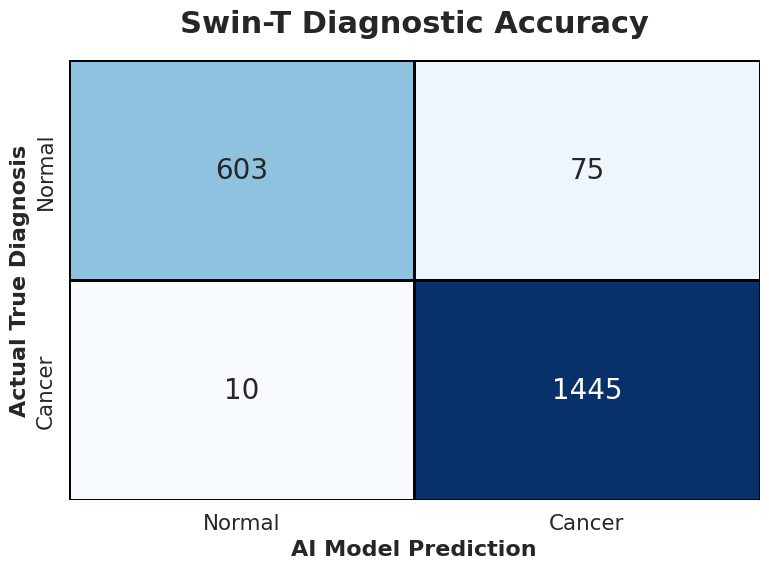

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Set up the plot style
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4) # Make the font large enough for a presentation slide

# Create a heatmap
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=['Normal', 'Cancer'],
                 yticklabels=['Normal', 'Cancer'],
                 annot_kws={"size": 20}, # Giant numbers for impact
                 linewidths=2, linecolor='black', cbar=False)

# Clean up the labels
plt.title('Swin-T Diagnostic Accuracy', fontsize=22, pad=20, fontweight='bold')
plt.ylabel('Actual True Diagnosis', fontsize=16, fontweight='bold')
plt.xlabel('AI Model Prediction', fontsize=16, fontweight='bold')

# Export the image in ultra-high resolution so it looks crisp on the slide
plt.tight_layout()
plt.savefig('swin_t_confusion_matrix.png', dpi=300)
plt.show()